In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import SGDOneClassSVM
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    fbeta_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.kernel_approximation import RBFSampler

In [2]:
X_train = pd.read_parquet("data").to_numpy(dtype=float)
validation_data = pd.read_parquet("benchmark")

In [3]:
X_val = validation_data.drop(columns=['label']).to_numpy(dtype=float)
y_val = validation_data['label'].values

In [4]:
y_val = np.where(y_val, -1, 1)

In [5]:
class VotingSGDOneClassSVM:
    def __init__(self, estimators):
        self.estimators = estimators

    def fit(self, X):        
        for label, model in self.estimators:
            print(f"Training for {label}")            
            model.fit(X)

    def predict(self, X):
        predictions = np.array([model.predict(X) for _, model in self.estimators])
        votes = np.sign(np.sum(predictions, axis=0))
        return votes

In [6]:
estimators = [
    ("nu: 0.07, tol: 1e-7, eta0: 1e-6", SGDOneClassSVM(nu=0.07, shuffle=True, learning_rate='constant', tol=1e-7, random_state=42, eta0=1e-6, max_iter=10000)),
    ("nu: 0.03, tol: 1e-7, eta0: 1e-6", SGDOneClassSVM(nu=0.03, shuffle=True, learning_rate='constant', tol=1e-7, random_state=42, eta0=1e-6, max_iter=10000)),
    ("nu: 0.05, tol: 1e-7, eta0: 1e-6", SGDOneClassSVM(nu=0.05, shuffle=True, learning_rate='constant', tol=1e-7, random_state=42, eta0=1e-6, max_iter=10000)),
    ("nu: 0.1, tol: 1e-7, eta0: 1e-6", SGDOneClassSVM(nu=0.1, shuffle=True, learning_rate='constant', tol=1e-7, random_state=42, eta0=1e-6, max_iter=10000)),
    ("nu: 0.2, tol: 1e-7, eta0: 1e-6", SGDOneClassSVM(nu=0.2, shuffle=True, learning_rate='constant', tol=1e-7, random_state=42, eta0=1e-6, max_iter=10000)),
    ("nu: 0.22, tol: 1e-7, eta0: 1e-6", SGDOneClassSVM(nu=0.22, shuffle=True, learning_rate='constant', tol=1e-7, random_state=42, eta0=1e-6, max_iter=10000)),
    ("nu: 0.07, tol: 1e-9, eta0: 1e-6", SGDOneClassSVM(nu=0.07, shuffle=True, learning_rate='constant', tol=1e-9, random_state=42, eta0=1e-6, max_iter=10000)),
    ("nu: 0.03, tol: 1e-9, eta0: 1e-6", SGDOneClassSVM(nu=0.03, shuffle=True, learning_rate='constant', tol=1e-9, random_state=42, eta0=1e-6, max_iter=10000)),
    ("nu: 0.05, tol: 1e-9, eta0: 1e-6", SGDOneClassSVM(nu=0.05, shuffle=True, learning_rate='constant', tol=1e-9, random_state=42, eta0=1e-6, max_iter=10000)),
    ("nu: 0.1, tol: 1e-9, eta0: 1e-6", SGDOneClassSVM(nu=0.1, shuffle=True, learning_rate='constant', tol=1e-9, random_state=42, eta0=1e-6, max_iter=10000)),
    ("nu: 0.2, tol: 1e-9, eta0: 1e-6", SGDOneClassSVM(nu=0.2, shuffle=True, learning_rate='constant', tol=1e-9, random_state=42, eta0=1e-6, max_iter=10000)),
    ("nu: 0.22, tol: 1e-9, eta0: 1e-6", SGDOneClassSVM(nu=0.22, shuffle=True, learning_rate='constant', tol=1e-9, random_state=42, eta0=1e-6, max_iter=10000)),
    ("nu: 0.07, tol: 1e-9, eta0: 1e-3", SGDOneClassSVM(nu=0.07, shuffle=True, learning_rate='constant', tol=1e-9, random_state=42, eta0=1e-3, max_iter=10000)),
    ("nu: 0.03, tol: 1e-9, eta0: 1e-3", SGDOneClassSVM(nu=0.03, shuffle=True, learning_rate='constant', tol=1e-9, random_state=42, eta0=1e-3, max_iter=10000)),
    ("nu: 0.05, tol: 1e-9, eta0: 1e-3", SGDOneClassSVM(nu=0.05, shuffle=True, learning_rate='constant', tol=1e-9, random_state=42, eta0=1e-3, max_iter=10000)),
    ("nu: 0.1, tol: 1e-9, eta0: 1e-3", SGDOneClassSVM(nu=0.1, shuffle=True, learning_rate='constant', tol=1e-9, random_state=42, eta0=1e-3, max_iter=10000)),
    ("nu: 0.22, tol: 1e-9, eta0: 1e-3", SGDOneClassSVM(nu=0.2, shuffle=True, learning_rate='constant', tol=1e-9, random_state=42, eta0=1e-3, max_iter=10000)),
    ("nu: 0.2, tol: 1e-9, eta0: 1e-3", SGDOneClassSVM(nu=0.22, shuffle=True, learning_rate='constant', tol=1e-9, random_state=42, eta0=1e-3, max_iter=10000)),
    ("nu: 0.07, tol: 1e-7, eta0: 1e-3", SGDOneClassSVM(nu=0.07, shuffle=True, learning_rate='constant', tol=1e-7, random_state=42, eta0=1e-3, max_iter=10000)),
    ("nu: 0.03, tol: 1e-7, eta0: 1e-3", SGDOneClassSVM(nu=0.03, shuffle=True, learning_rate='constant', tol=1e-7, random_state=42, eta0=1e-3, max_iter=10000)),
    ("nu: 0.05, tol: 1e-7, eta0: 1e-3", SGDOneClassSVM(nu=0.05, shuffle=True, learning_rate='constant', tol=1e-7, random_state=42, eta0=1e-3, max_iter=10000)),
    ("nu: 0.1, tol: 1e-7, eta0: 1e-3", SGDOneClassSVM(nu=0.1, shuffle=True, learning_rate='constant', tol=1e-7, random_state=42, eta0=1e-3, max_iter=10000)),
    ("nu: 0.2, tol: 1e-7, eta0: 1e-3", SGDOneClassSVM(nu=0.2, shuffle=True, learning_rate='constant', tol=1e-7, random_state=42, eta0=1e-3, max_iter=10000)),
    ("nu: 0.22, tol: 1e-7, eta0: 1e-3", SGDOneClassSVM(nu=0.22, shuffle=True, learning_rate='constant', tol=1e-7, random_state=42, eta0=1e-3, max_iter=10000))
]

rbf_sampler = RBFSampler(gamma=0.01, n_components=1000, random_state=42)
X_batch_transformed = rbf_sampler.fit_transform(X_train)

sgd_oc_svm_voting = VotingSGDOneClassSVM(estimators)

sgd_oc_svm_voting.fit(X_batch_transformed)

X_val_transformed = rbf_sampler.transform(X_val)

Training for nu: 0.07, tol: 1e-7, eta0: 1e-6
Training for nu: 0.03, tol: 1e-7, eta0: 1e-6
Training for nu: 0.05, tol: 1e-7, eta0: 1e-6
Training for nu: 0.1, tol: 1e-7, eta0: 1e-6
Training for nu: 0.2, tol: 1e-7, eta0: 1e-6
Training for nu: 0.22, tol: 1e-7, eta0: 1e-6
Training for nu: 0.07, tol: 1e-9, eta0: 1e-6
Training for nu: 0.03, tol: 1e-9, eta0: 1e-6
Training for nu: 0.05, tol: 1e-9, eta0: 1e-6
Training for nu: 0.1, tol: 1e-9, eta0: 1e-6
Training for nu: 0.2, tol: 1e-9, eta0: 1e-6
Training for nu: 0.22, tol: 1e-9, eta0: 1e-6
Training for nu: 0.07, tol: 1e-9, eta0: 1e-3
Training for nu: 0.03, tol: 1e-9, eta0: 1e-3
Training for nu: 0.05, tol: 1e-9, eta0: 1e-3
Training for nu: 0.1, tol: 1e-9, eta0: 1e-3
Training for nu: 0.22, tol: 1e-9, eta0: 1e-3
Training for nu: 0.2, tol: 1e-9, eta0: 1e-3
Training for nu: 0.07, tol: 1e-7, eta0: 1e-3
Training for nu: 0.03, tol: 1e-7, eta0: 1e-3
Training for nu: 0.05, tol: 1e-7, eta0: 1e-3
Training for nu: 0.1, tol: 1e-7, eta0: 1e-3
Training for nu: 

In [8]:
y_pred = sgd_oc_svm_voting.predict(X_val_transformed)
y_pred = np.where(y_pred == 0, -1, 1)

[np.int64(1), np.int64(-1)]


Classification Report:
              precision    recall  f1-score   support

   Anomalous       0.20      0.01      0.02     14034
      Normal       0.78      0.99      0.87     50702

    accuracy                           0.78     64736
   macro avg       0.49      0.50      0.45     64736
weighted avg       0.66      0.78      0.69     64736

Accuracy: 0.78


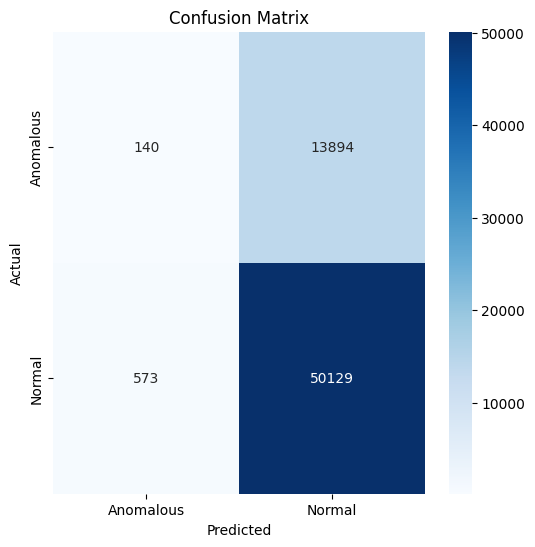

Precision: 0.78, Recall: 0.99, F1-Score: 0.87
AUC Score: 0.50
F2-Score: 0.94


In [9]:
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=["Anomalous", "Normal"]))

accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy:.2f}")

cm = confusion_matrix(y_val, y_pred, labels=[-1, 1])

plt.figure(figsize=(6, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Anomalous", "Normal"],
    yticklabels=["Anomalous", "Normal"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

precision = precision_score(y_val, y_pred, pos_label=1)
recall = recall_score(y_val, y_pred, pos_label=1)
f1 = f1_score(y_val, y_pred, pos_label=1)
print(f"Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1:.2f}")

auc = roc_auc_score(y_val, y_pred)
print(f"AUC Score: {auc:.2f}")

f2 = fbeta_score(y_val, y_pred, beta=2, pos_label=1)
print(f"F2-Score: {f2:.2f}")